
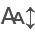

In [1]:
from itables import init_notebook_mode, show
import numpy as np
import torch
import torch.optim as optim
from torchviz import make_dot
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

import importlib
import aacbr_torch

init_notebook_mode(all_interactive=True)

In [2]:
def reload_imports():
    importlib.reload(aacbr_torch)

## Data Set

In [3]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# # data (as pandas dataframes) 
# X = connectionist_bench_sonar_mines_vs_rocks.data.features 
# y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))



['M' 'R']


In [4]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)


In [5]:
print(encoder.classes_)
print(y)
print(type(y))

['M' 'R']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
<class 'numpy.ndarray'>


## Train Model

### Split into Training and Test Sets

In [6]:
SEED = 42

In [7]:
X, y = torch.tensor(X), torch.tensor(y, dtype=torch.float32)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")



Test Size:  42
Train Size:  132
Validation Size:  33


In [8]:
print(X_train)

tensor([[0.0176, 0.0172, 0.0501,  ..., 0.0179, 0.0294, 0.0063],
        [0.0195, 0.0142, 0.0181,  ..., 0.0042, 0.0067, 0.0012],
        [0.0294, 0.0123, 0.0117,  ..., 0.0006, 0.0081, 0.0043],
        ...,
        [0.0423, 0.0321, 0.0709,  ..., 0.0021, 0.0043, 0.0017],
        [0.0409, 0.0421, 0.0573,  ..., 0.0061, 0.0030, 0.0078],
        [0.0132, 0.0080, 0.0188,  ..., 0.0140, 0.0028, 0.0064]])


### Build AF

In [9]:
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

In [10]:
COMPARISON_FUNC = aacbr_torch.LearnedPartialOrder(X_train.shape[1])
PREPROCESS_FUNC = lambda x: x 

In [11]:
DEFAULT_OUTCOME = 1
DEFAULT_CASE = means.clone()
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
USE_SYMM_ATTACKS = False

In [12]:
reload_imports()
def run_model(X_train, y_train, X_test, y_test, comparison_func = COMPARISON_FUNC, print_graph=False, print_matrix=False, print_compute=False, print_params=False, backward=False):
    X_train = PREPROCESS_FUNC(X_train)
    X_test = PREPROCESS_FUNC(X_test)
    default_case = PREPROCESS_FUNC(DEFAULT_CASE)
    
    model = aacbr_torch.AACBRTorch(X_train, y_train, comparison_func, default_case, 
                                   torch.tensor([DEFAULT_OUTCOME]), use_symmetric_attacks=USE_SYMM_ATTACKS)
    predicted = model(X_test)

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()
    
    criterion = torch.nn.BCELoss()
    loss = criterion(predicted.squeeze(), y_test)

    if print_compute:
        make_dot(loss, params=dict(model.named_parameters())).render("aacbr_torch", format="pdf")

    # if backward:
    #     loss.backward()
    
        

    if print_params:
        print("Predicted requires_grad", predicted.requires_grad)
        for name, param in model.named_parameters():
            print(f"Parameter: {name}, Shape: {param.shape}")
            print(param)

    y_test = y_test.detach().cpu().numpy()
    predicted = torch.round(predicted).detach().cpu().numpy()
    return([
        accuracy_score(y_test, predicted),
        precision_score(y_test, predicted),
        recall_score(y_test, predicted),
        f1_score(y_test, predicted)
    ])

### Cross-Validation

In [13]:
# reload_imports()
# metrics = []
# for fold, (train_index,  val_index) in enumerate(kf.split(X_train)):
#     training_instances = X_train[train_index]
#     training_labels = y_train[train_index]
#     validation_instances = X_train[val_index]
#     validation_labels = y_train[val_index]


#     metrics.append(
#         run_model(training_instances, training_labels, validation_instances, validation_labels)
#     )

# print("Accuracy, Precision, Recall, F1")
# print(np.mean(metrics, axis=0))
# # for metric in metrics:
# #     print(metric)


### Validation Set

In [14]:
import numpy as np
np.set_printoptions(threshold=10_000)
torch.set_printoptions(edgeitems=1000000)

In [15]:
# run_model(X_train_full, y_train_full, X_val, y_val, print_matrix=True, print_compute=True)

## Train Loop

In [78]:
reload_imports()
torch.manual_seed(1) # TRY DIFFERENT INITIAL WEIGHTS 

EPOCHS = 75 
# EPOCHS = 5
default_case = PREPROCESS_FUNC(DEFAULT_CASE)
learned_order = aacbr_torch.LearnedPartialOrder(X_train.shape[1])

criterion = torch.nn.BCELoss()
                                   
model = aacbr_torch.AACBRTorch(X_train, y_train, learned_order, default_case, 
                            torch.tensor([DEFAULT_OUTCOME]), use_symmetric_attacks=USE_SYMM_ATTACKS)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

model.train()


torch.Size([2352637])
torch.Size([2352637])


AACBRTorch(
  (comparison_func): LearnedPartialOrder()
)

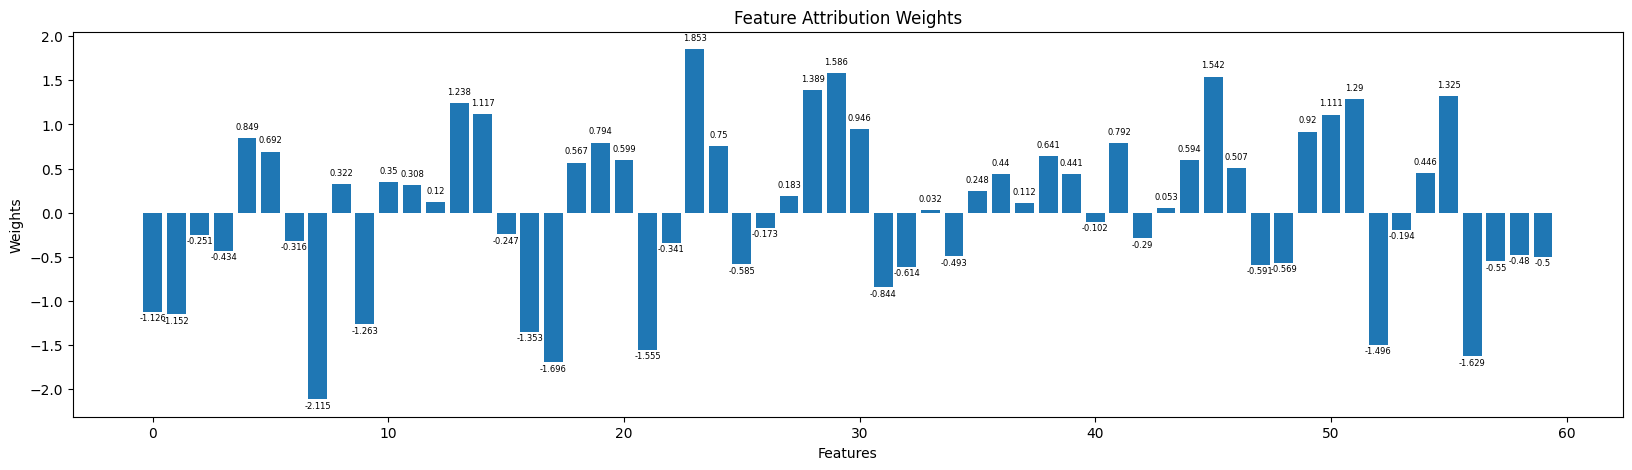

In [56]:
learned_order.plot_parameters()

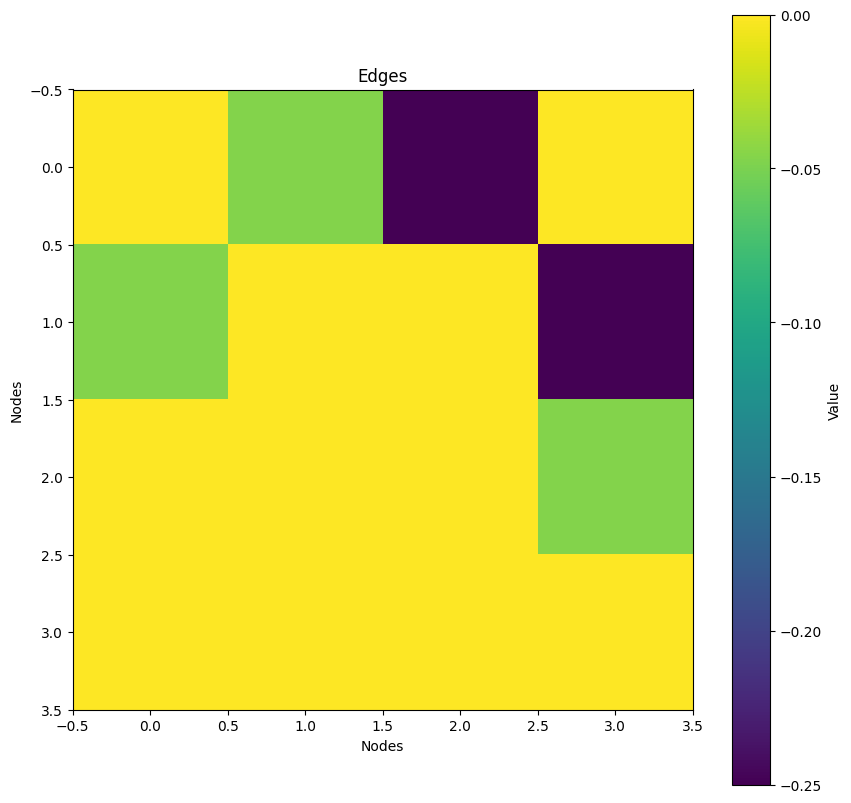

Model with symm
TRUE
Attack targets before tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e-01, 5.0000e-01,
        5.0000e-01, 5.0000e-01, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e-01, 5.0000e-01,
        5.0000e-01, 5.0000e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 2.0575e-25, 2.0575e-25, 2.0575e-25, 2.0575e-25,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 5.0000e-01, 5.0000e-01, 5.0000e-01, 5.0000e-01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0575e-25, 2.0575e-25,
        2.0575e-25, 2.0575e-25, 5.0000e-01, 5.0000e-01, 5.0000e-01, 5.0000e-01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
       grad_fn=<MulBackward0>)
Symm mask: tensor([[[ True,  True,  True,  True],
         [ True,  T

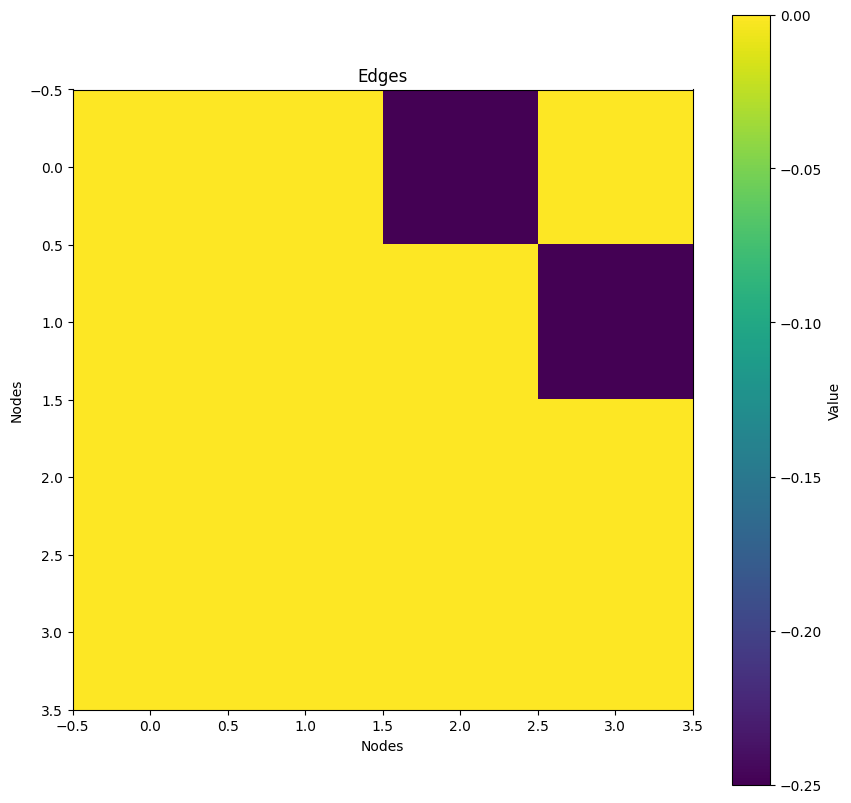

Model without symm


In [96]:
reload_imports()

X_train = torch.tensor([
    [0, 0, 0, 1],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
], dtype=torch.float32)

y_train = torch.tensor([1, 0, 0], dtype=torch.float32)

default_case = torch.tensor([0, 0, 0, 0], dtype=torch.float32)

torch.manual_seed(0) # TRY DIFFERENT INITIAL WEIGHTS 
learned_order = aacbr_torch.LearnedPartialOrder(X_train.shape[1])
model = aacbr_torch.AACBRTorch(X_train, y_train, learned_order, default_case, 
                            torch.tensor([DEFAULT_OUTCOME]), use_symmetric_attacks=True)
model.show_matrix()
print("Model with symm")
model.has_symmetric_attacks()

model = aacbr_torch.AACBRTorch(X_train, y_train, learned_order, default_case, 
                            torch.tensor([DEFAULT_OUTCOME]), use_symmetric_attacks=False)
model.show_matrix()
print("Model without symm")
model.has_symmetric_attacks()

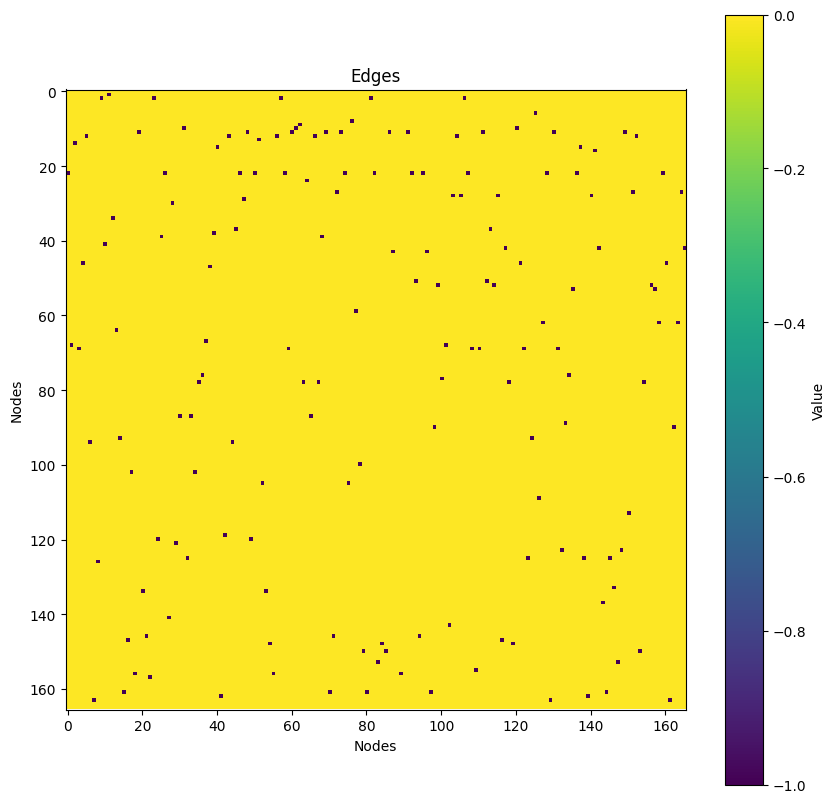

[0.42424242424242425, 0.4117647058823529, 0.4375, 0.42424242424242425]

In [57]:
run_model(X_train_full, y_train_full, X_val, y_val, comparison_func=learned_order, print_matrix=True, print_compute=False)

In [45]:
# torch.autograd.set_detect_anomaly(True)
# torch.autograd.set_detect_anomaly(False)

In [46]:
DISABLE_TQDM = False

Fold: 0


Epoch 75, Loss: 1.5089: 100%|██████████| 75/75 [00:21<00:00,  3.44it/s]


Fold: 1


Epoch 75, Loss: 1.5089: 100%|██████████| 75/75 [00:21<00:00,  3.43it/s]


Fold: 2


Epoch 75, Loss: 1.7751: 100%|██████████| 75/75 [00:21<00:00,  3.44it/s]


Fold: 3


Epoch 75, Loss: 1.9231: 100%|██████████| 75/75 [00:21<00:00,  3.47it/s]


Fold: 4


Epoch 75, Loss: 1.6272: 100%|██████████| 75/75 [00:21<00:00,  3.48it/s]

Finished Training


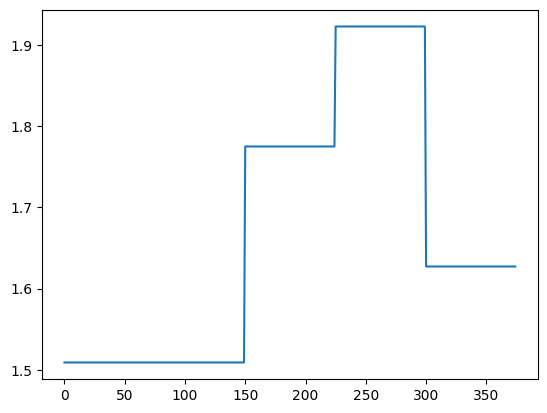

In [58]:
reload_imports()
def train():
    losses = []
    for fold, (casebase_index,  new_cases_index) in enumerate(kf.split(X_train)):

        print("Fold:", fold)

        # casebase = X_train[casebase_index]
        # casebase_labels = y_train[casebase_index]

        new_cases = X_train[new_cases_index]
        new_cases_labels = y_train[new_cases_index]

        model.set_casebase_indices(torch.tensor(casebase_index))
        # TODO: If we build each epoch, building here is uncessary but if we aim to build only each fold
        # need to find a new solution for gradient accumulation
        # model.build_af_parallel()
    
        pbar = tqdm(range(EPOCHS), disable=DISABLE_TQDM)

        for epoch in pbar:  
            # print(f"Executing epoch {epoch}")

            running_loss = 0.0
            optimizer.zero_grad()

            # TODO: consider efficiency issues with having to rebuild each time 
            # Find a way to accumulate gradients update only when necessary?
            model.build_af_parallel()
            predictions = model(new_cases).squeeze()

            loss = criterion(predictions, new_cases_labels)
            loss.backward()

            optimizer.step()

            running_loss += loss.item()
            losses.append(running_loss/len(new_cases))

            pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(running_loss/len(new_cases), 4)}')
        # make_dot(loss, params=dict(model.named_parameters())).render(f"aacbr_torch_fold{fold}_epoch{epoch}", format="pdf")




   

    print('Finished Training')

    plt.plot(losses)
    plt.show()

train()

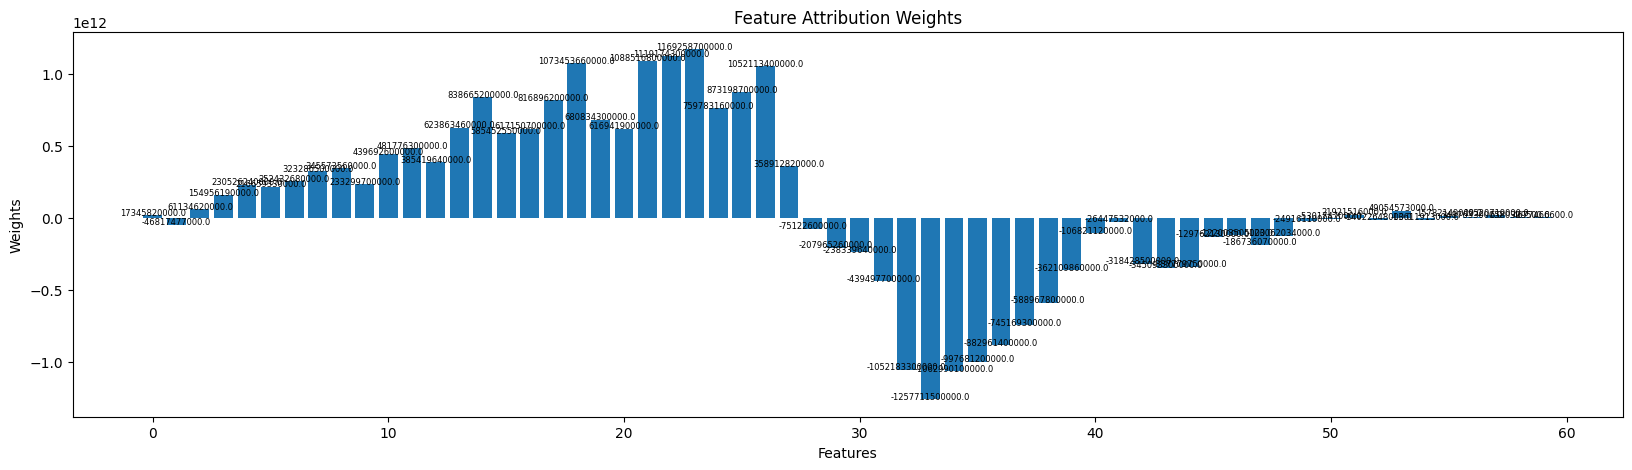

In [59]:
learned_order.plot_parameters()

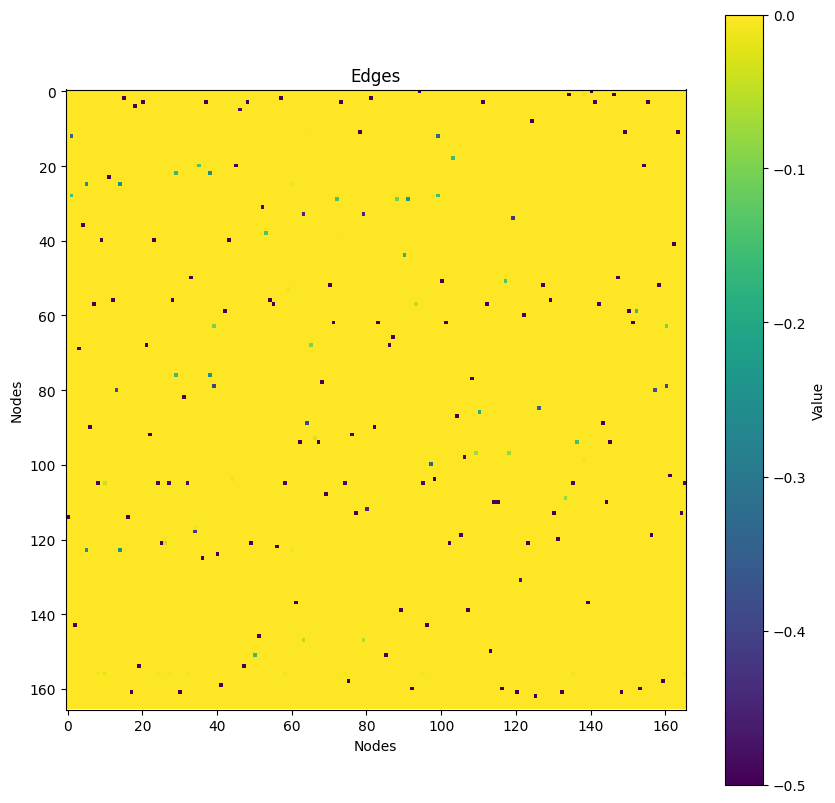

[0.48484848484848486, 0.48484848484848486, 1.0, 0.6530612244897959]

In [49]:

run_model(X_train_full, y_train_full, X_val, y_val, comparison_func=learned_order, print_matrix=True, print_compute=True)

### Test Set

In [50]:
# reload_imports()
# print("Accuracy, Precision, Recall, F1")
# run_model(X_train_full, y_train_full, X_test, y_test, show_graph=False)